<a href="https://colab.research.google.com/github/Keistkmiya/Tugas1-MachineLearning/blob/main/Tugas1_Chapter4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4: Representing Data and Engineering Features

## Setup and Library Imports

In [ ]:
!pip install mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 9.3 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mglearn
from sklearn.model_selection import train_test_split

%matplotlib inline

## Categorical Variables (One-Hot-Encoding)

Sebagian besar algoritma machine learning hanya bisa menerima angka sebagai input. One-Hot-Encoding (atau dummy variables) adalah cara paling umum untuk mengubah data kategori (seperti nama negara atau jenis pekerjaan) menjadi angka 0 dan 1 agar bisa diproses oleh model.

In [ ]:
data = pd.read_csv(
    os.path.join(mglearn.datasets.DATA_PATH, "adult.data"),
    header=None, index_col=False,
    names=['age', 'workclass', 'fnlwgt', 'education', 'education-num',
           'marital-status', 'occupation', 'relationship', 'race', 'gender',
           'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
           'income'])

data = data[['age', 'workclass', 'education', 'gender', 'hours-per-week',
             'occupation', 'income']]

display(data.head())

,age,workclass,education,gender,hours-per-week,occupation,income
0,39,State-gov,Bachelors,Male,40,Adm-clerical,<=50K
1,50,Self-emp-not-inc,Bachelors,Male,13,Exec-managerial,<=50K
2,38,Private,HS-grad,Male,40,Handlers-cleaners,<=50K
3,53,Private,11th,Male,40,Handlers-cleaners,<=50K
4,28,Private,Bachelors,Female,40,Prof-specialty,<=50K


### Checking String-Encoded Categorical Data

In [5]:
print(data.gender.value_counts())

gender
Male      21790
Female    10771
Name: count, dtype: int64


### One-Hot-Encoding with pandas (get_dummies)

Fungsi get_dummies dari pandas secara otomatis akan mengubah semua kolom yang bertipe objek (string) menjadi kolom-kolom baru berisi angka 0 dan 1. Kolom yang sudah berisi angka (seperti age atau hours-per-week) tidak akan diubah oleh fungsi ini.

In [6]:
data_dummies = pd.get_dummies(data)

print("Original features:\n", list(data.columns), "\n")
print("Features after get_dummies:\n", list(data_dummies.columns))

Original features:
 ['age', 'workclass', 'education', 'gender', 'hours-per-week', 'occupation', 'income'] 

Features after get_dummies:
 ['age', 'hours-per-week', 'workclass_ ?', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Never-worked', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'education_ 10th', 'education_ 11th', 'education_ 12th', 'education_ 1st-4th', 'education_ 5th-6th', 'education_ 7th-8th', 'education_ 9th', 'education_ Assoc-acdm', 'education_ Assoc-voc', 'education_ Bachelors', 'education_ Doctorate', 'education_ HS-grad', 'education_ Masters', 'education_ Preschool', 'education_ Prof-school', 'education_ Some-college', 'gender_ Female', 'gender_ Male', 'occupation_ ?', 'occupation_ Adm-clerical', 'occupation_ Armed-Forces', 'occupation_ Craft-repair', 'occupation_ Exec-managerial', 'occupation_ Farming-fishing', 'occupation_ Handlers-cleaners', 'occupation_ Machine-op-i

In [7]:
display(data_dummies.head())

,age,hours-per-week,workclass_ ?,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Never-worked,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving,income_ <=50K,income_ >50K
0,39,40,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
1,50,13,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,38,40,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,53,40,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,28,40,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False


### Extracting Features and Target

In [8]:
features = data_dummies.loc[:, 'age':'occupation_ Transport-moving']

X = features.values
y = data_dummies['income_ >50K'].values

print("X.shape: {}  y.shape: {}".format(X.shape, y.shape))

X.shape: (32561, 44)  y.shape: (32561,)


### Logistic Regression for Categorical Data

In [10]:
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

print("Test score: {:.2f}".format(logreg.score(X_test, y_test)))

Test score: 0.82


### Numbers Can Encode Categoricals

Terkadang data kategori sudah tersimpan dalam bentuk angka (integer). Masalahnya, secara default get_dummies hanya akan mengubah kolom yang bertipe string (objek). Jika kolom kategori kita berisi angka, pandas akan menganggapnya sebagai data kontinu dan tidak akan membuatkan kolom dummy.

In [11]:
demo_df = pd.DataFrame({'Integer Feature': [0, 1, 2, 1],
                        'Categorical Feature': ['socks', 'fox', 'socks', 'box']})
display(demo_df)

,Integer Feature,Categorical Feature
0,0,socks
1,1,fox
2,2,socks
3,1,box


In [12]:
pd.get_dummies(demo_df)

,Integer Feature,Categorical Feature_box,Categorical Feature_fox,Categorical Feature_socks
0,0,False,False,True
1,1,False,True,False
2,2,False,False,True
3,1,True,False,False


In [13]:
pd.get_dummies(demo_df, columns=['Integer Feature', 'Categorical Feature'])

,Integer Feature_0,Integer Feature_1,Integer Feature_2,Categorical Feature_box,Categorical Feature_fox,Categorical Feature_socks
0,True,False,False,False,False,True
1,False,True,False,False,True,False
2,False,False,True,False,False,True
3,False,True,False,True,False,False


### One-Hot-Encoding with scikit-learn (OneHotEncoder)

Meskipun get_dummies sangat praktis, OneHotEncoder dari scikit-learn adalah standar yang digunakan dalam machine learning pipeline. Keunggulan utamanya adalah ia bisa "mengingat" kategori dari data training dan menerapkannya dengan konsisten pada data baru, sehingga mencegah error jika ada kategori yang hilang atau urutannya berubah.

In [14]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
ohe_results = ohe.fit_transform(demo_df[['Categorical Feature']])

print("Hasil encoding (Array):\n", ohe_results)
print("\nNama fitur yang dihasilkan:\n", ohe.get_feature_names_out())

Hasil encoding (Array):
 [[0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]

Nama fitur yang dihasilkan:
 ['Categorical Feature_box' 'Categorical Feature_fox'
 'Categorical Feature_socks']


In [15]:
ohe_all = OneHotEncoder(sparse_output=False)
ohe_results_all = ohe_all.fit_transform(demo_df)

print("Nama fitur baru:\n", ohe_all.get_feature_names_out())

Nama fitur baru:
 ['Integer Feature_0' 'Integer Feature_1' 'Integer Feature_2'
 'Categorical Feature_box' 'Categorical Feature_fox'
 'Categorical Feature_socks']


## Binning, Discretization, Linear Models, and Trees

Model linear hanya bisa memodelkan hubungan linear. Jika hubungan antara fitur dan target bersifat non-linear (misalnya bergelombang atau naik-turun), model linear akan kesulitan. Dengan Binning, kita membagi rentang nilai fitur menjadi beberapa "keranjang" (bins), sehingga model bisa mempelajari pola yang berbeda untuk setiap rentang tersebut.

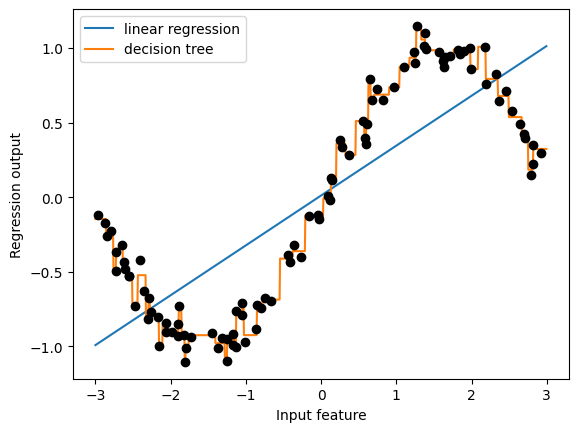

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

def make_wave(n_samples=100):
    rnd = np.random.RandomState(42)
    x = rnd.uniform(-3, 3, size=n_samples)
    y_no_noise = np.sin(x)
    y = y_no_noise + rnd.normal(size=n_samples) / 10
    return x.reshape(-1, 1), y

X, y = make_wave(n_samples=100)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)

reg = LinearRegression().fit(X, y)
plt.plot(line, reg.predict(line), label="linear regression")

tree = DecisionTreeRegressor(min_samples_split=3).fit(X, y)
plt.plot(line, tree.predict(line), label="decision tree")

plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")

### Binning with KBinsDiscretizer

In [17]:
from sklearn.preprocessing import KBinsDiscretizer

kb = KBinsDiscretizer(n_bins=10, strategy='uniform', encode='onehot')
kb.fit(X)
X_binned = kb.transform(X)

print("Data asli:\n", X[:5])
print("\nHasil binning (dalam bentuk sparse matrix):\n", X_binned[:5].toarray())

Data asli:
 [[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]

Hasil binning (dalam bentuk sparse matrix):
 [[0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]


Text(0.5, 0, 'Input feature')

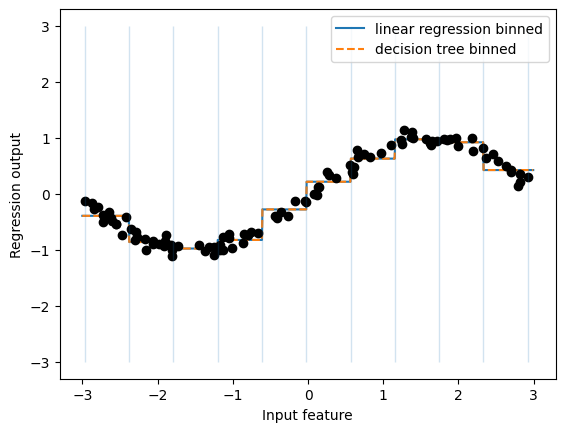

In [18]:
line_binned = kb.transform(line)

reg = LinearRegression().fit(X_binned, y)
plt.plot(line, reg.predict(line_binned), label='linear regression binned')

tree = DecisionTreeRegressor(min_samples_split=3).fit(X_binned, y)
plt.plot(line, tree.predict(line_binned), label='decision tree binned', linestyle='--')

plt.plot(X[:, 0], y, 'o', c='k')
plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)
plt.legend(loc="best")
plt.ylabel("Regression output")
plt.xlabel("Input feature")

## Interactions and Polynomials

In [19]:
import numpy as np

X_product = np.hstack([X_binned.toarray(), X * X_binned.toarray()])

print("Bentuk data baru (Interaction):", X_product.shape)

Bentuk data baru (Interaction): (100, 20)


Text(0.5, 0, 'Input feature')

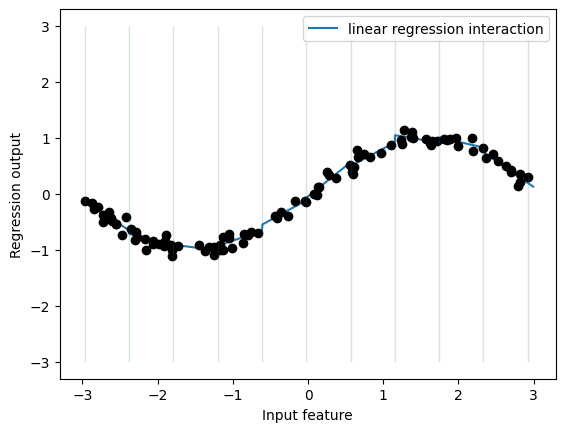

In [20]:
line_product = np.hstack([line_binned.toarray(), line * line_binned.toarray()])
reg = LinearRegression().fit(X_product, y)
plt.plot(line, reg.predict(line_product), label='linear regression interaction')

plt.plot(X[:, 0], y, 'o', c='k')
plt.vlines(kb.bin_edges_[0], -3, 3, linewidth=1, alpha=.2)
plt.legend(loc="best")
plt.ylabel("Regression output")
plt.xlabel("Input feature")

### Polynomial Features

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=10, include_bias=False)
poly.fit(X)
X_poly = poly.transform(X)

print("Bentuk data asli:", X.shape)
print("Bentuk data polynomial:", X_poly.shape)
print("\n5 baris pertama fitur polynomial:\n", X_poly[:5])

Bentuk data asli: (100, 1)
Bentuk data polynomial: (100, 10)

5 baris pertama fitur polynomial:
 [[-7.52759287e-01  5.66646544e-01 -4.26548448e-01  3.21088306e-01
  -2.41702204e-01  1.81943579e-01 -1.36959719e-01  1.03097700e-01
  -7.76077513e-02  5.84199555e-02]
 [ 2.70428584e+00  7.31316190e+00  1.97768801e+01  5.34823369e+01
   1.44631526e+02  3.91124988e+02  1.05771377e+03  2.86036036e+03
   7.73523202e+03  2.09182784e+04]
 [ 1.39196365e+00  1.93756281e+00  2.69701700e+00  3.75414962e+00
   5.22563982e+00  7.27390068e+00  1.01250053e+01  1.40936394e+01
   1.96178338e+01  2.73073115e+01]
 [ 5.91950905e-01  3.50405874e-01  2.07423074e-01  1.22784277e-01
   7.26822637e-02  4.30243318e-02  2.54682921e-02  1.50759786e-02
   8.92423917e-03  5.28271146e-03]
 [-2.06388816e+00  4.25963433e+00 -8.79140884e+00  1.81444846e+01
  -3.74481869e+01  7.72888694e+01 -1.59515582e+02  3.29222321e+02
  -6.79478050e+02  1.40236670e+03]]


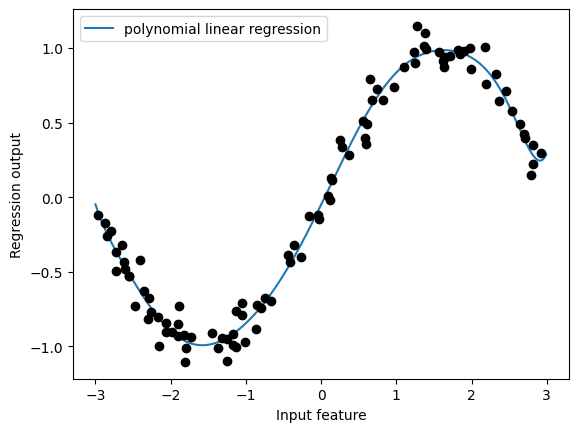

In [22]:
line_poly = poly.transform(line)
reg = LinearRegression().fit(X_poly, y)

plt.plot(line, reg.predict(line_poly), label='polynomial linear regression')
plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")

## Univariate Nonlinear Transformations

Tujuan utama dari transformasi ini adalah membuat distribusi fitur kita menjadi lebih "normal" (Gaussian). Banyak model linear, seperti Linear Regression atau Logistic Regression, bekerja jauh lebih optimal jika data tidak memiliki ekor yang terlalu panjang atau penumpukan di satu sisi saja (skewed data).

Text(0.5, 0, 'Value')

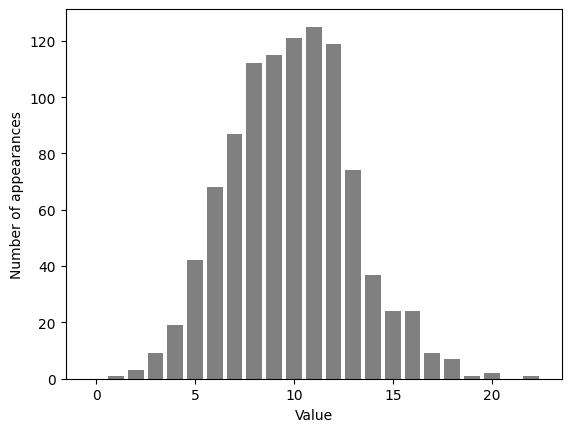

In [23]:
import numpy as np
import matplotlib.pyplot as plt

rnd = np.random.RandomState(0)
X_org = rnd.poisson(10, size=(1000, 3))
y = rnd.normal(size=(1000,))

bins = np.bincount(X_org[:, 0])
plt.bar(range(len(bins)), bins, color='grey')
plt.ylabel("Number of appearances")
plt.xlabel("Value")

Text(0.5, 0, 'Value (log scale)')

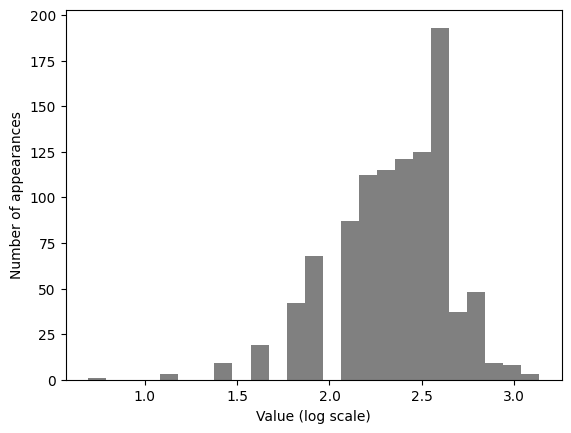

In [24]:
X_log = np.log(X_org + 1)

plt.hist(X_log[:, 0], bins=25, color='grey')
plt.ylabel("Number of appearances")
plt.xlabel("Value (log scale)")

In [25]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_org, y, random_state=0)
score = Ridge().fit(X_train, y_train).score(X_test, y_test)
print("Skor R^2 pada data asli: {:.3f}".format(score))

X_train_log, X_test_log, y_train, y_test = train_test_split(X_log, y, random_state=0)
score_log = Ridge().fit(X_train_log, y_train).score(X_test_log, y_test)
print("Skor R^2 pada data log: {:.3f}".format(score_log))

Skor R^2 pada data asli: -0.009
Skor R^2 pada data log: -0.006


### Univariate Statistics
Dalam seleksi fitur univariat, kita menghitung apakah ada hubungan yang signifikan secara statistik antara setiap fitur dan target. Fitur yang memiliki tingkat kepercayaan (confidence) paling tinggi akan dipilih. Teknik ini disebut **univariat** karena hanya mempertimbangkan satu fitur dalam satu waktu, tanpa melihat apakah fitur tersebut punya "kerja sama" (interaksi) dengan fitur lainnya.

In [27]:
from sklearn.feature_selection import SelectPercentile
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()

rng = np.random.RandomState(42)
noise = rng.normal(size=(len(cancer.data), 50))

X_w_noise = np.hstack([cancer.data, noise])

X_train, X_test, y_train, y_test = train_test_split(
    X_w_noise, cancer.target, random_state=0, test_size=.5)

select = SelectPercentile(percentile=50)
select.fit(X_train, y_train)

X_train_selected = select.transform(X_train)

print("Bentuk X_train awal:", X_train.shape)
print("Bentuk X_train setelah diseleksi:", X_train_selected.shape)

Bentuk X_train awal: (284, 80)
Bentuk X_train setelah diseleksi: (284, 40)


([], [])

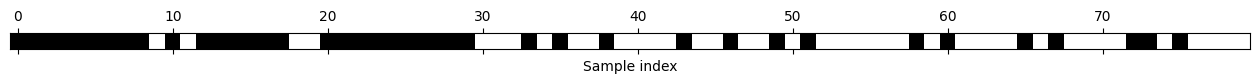

In [28]:
mask = select.get_support()

plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")
plt.yticks(())

In [29]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
print("Skor dengan semua fitur: {:.3f}".format(lr.score(X_test, y_test)))

lr.fit(X_train_selected, y_train)
X_test_selected = select.transform(X_test)
print("Skor dengan fitur pilihan: {:.3f}".format(lr.score(X_test_selected, y_test)))

Skor dengan semua fitur: 0.951
Skor dengan fitur pilihan: 0.933


### Model-Based Feature Selection

Seleksi fitur berbasis model menggunakan model machine learning (seperti Random Forest) untuk menentukan seberapa penting setiap fitur. Berbeda dengan seleksi univariat, metode ini mempertimbangkan interaksi antar fitur. Saya akan menggunakan `SelectFromModel` untuk memilih fitur yang memiliki nilai penting di atas ambang batas (median).

In [30]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

select = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42),
    threshold="median")

select.fit(X_train, y_train)
X_train_l1 = select.transform(X_train)

print("Bentuk X_train awal:", X_train.shape)
print("Bentuk X_train dengan Model-based selection:", X_train_l1.shape)

Bentuk X_train awal: (284, 80)
Bentuk X_train dengan Model-based selection: (284, 40)


([], [])

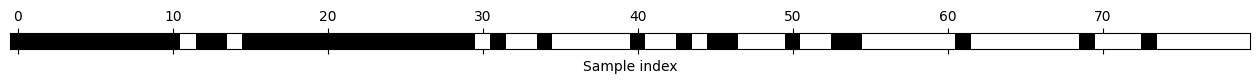

In [31]:
mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")
plt.yticks(())

Pada grafik di atas, terlihat bahwa seleksi berbasis model jauh lebih akurat dalam mengidentifikasi fitur asli (indeks 0-29). Hampir semua fitur asli terpilih (berwarna hitam), dan hampir semua fitur sampah berhasil dibuang. Sekarang saya akan membandingkan performa Logistic Regression menggunakan fitur pilihan ini.

In [32]:
X_test_l1 = select.transform(X_test)
score = LogisticRegression(max_iter=5000).fit(X_train_l1, y_train).score(X_test_l1, y_test)
print("Skor Test dengan Model-based selection: {:.3f}".format(score))

Skor Test dengan Model-based selection: 0.947


### Iterative Feature Selection (RFE)

Dalam Recursive Feature Elimination (RFE), saya memulai dengan semua fitur, membangun model, dan membuang fitur yang paling tidak penting. Proses ini diulangi terus-menerus sampai jumlah fitur yang diinginkan tercapai. Karena menjalankan banyak model secara berurutan, metode ini jauh lebih lama prosesnya dibandingkan dua metode sebelumnya.

([], [])

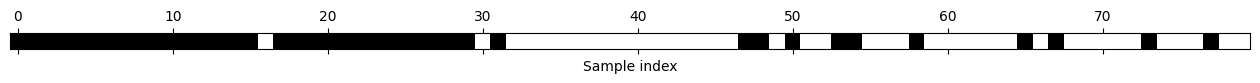

In [33]:
from sklearn.feature_selection import RFE

select = RFE(RandomForestClassifier(n_estimators=100, random_state=42),
             n_features_to_select=40)

select.fit(X_train, y_train)

mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")
plt.yticks(())

In [34]:
X_train_rfe = select.transform(X_train)
X_test_rfe = select.transform(X_test)

score = LogisticRegression(max_iter=5000).fit(X_train_rfe, y_train).score(X_test_rfe, y_test)
print("Skor Test dengan RFE: {:.3f}".format(score))

Skor Test dengan RFE: 0.940
